# TEST EVOLUTIEMODEL

Deze eerste test betreft een berekening over 20 jaar, waarbij jaarlijks de globale degradatie-index wordt bepaald.

## Berekeningsmethode

De degradatie per jaar wordt op twee manieren berekend:

### 1. Totaal per jaar (jaarlijkse berekening)

Voor elk jaar wordt de degradatie opnieuw berekend met de volgende stappen:

```plaintext
yt = 0.9 - (x * B * T)
y  = x * B
cumul = cumul + y
yt = 0.9 - cumul


# TEST EVOLUTIE MODEL

Eerste test is een 20 jaar berekening dat globale index (degradatie) berekend per jaar.
vb:
| totaal perjaar                | met cumul             |
|-------------------------------|-----------------------|
| yt = 0.9 - (x * B * T) (voor jaar T) | y = x * B         |
|  | cumul = cumul + y    |
|    | yt = 0.9 - cumul             |
| yt = 0.9 - (x * B * T2) | y = x * B         |
|  | cumul = cumul + y    |
|    | yt = 0.9 - cumul             |

Met de cumul berekening ga je voor ieder jaar afzonderlijk de degradatie berekenen. De jaren na het onderhoudstype gaat deze afhankelijk van het onderhoud gereset worden.
Met de jaarlijkse berekening nemen dan gaat deze paramterer (hoe snel een weg erop achteruit gaat) ook over de eerder jaren gebruikt worden en is er plots een grote daling. 


##### result totaal per jaar:
- JAAR 1 => visueel: 0.88 - structureel: 0.876 - globaal: 0.878
- JAAR 2 => visueel: 0.86 - structureel: 0.852 - globaal: 0.856
- JAAR 3 => visueel: 0.84 - structureel: 0.828 - globaal: 0.834
- JAAR 4 => visueel: 0.82 - structureel: 0.8039999999999999 - globaal: 0.8119999999999999
- __JAAR 5 => visueel: 0.7999999999999999 - structureel: 0.7799999999999999 - globaal: 0.7899999999999999__
- JAAR 6 => visueel: 0.845 - structureel: 0.7559999999999999 - globaal: 0.8005
- __JAAR 7 => visueel: 0.7899999999999999 - structureel: 0.7319999999999999 - globaal: 0.7609999999999999__
- JAAR 8 => visueel: 0.845 - structureel: 0.7079999999999999 - globaal: 0.7765
- JAAR 9 => visueel: 0.7899999999999999 - structureel: 0.6839999999999998 - globaal: 0.7369999999999999
- JAAR 10 => visueel: 0.7349999999999999 - structureel: 0.6599999999999998 - globaal: 0.6974999999999998
- JAAR 11 => visueel: 0.6799999999999998 - structureel: 0.6359999999999998 - globaal: 0.6579999999999998
- JAAR 12 => visueel: 0.6249999999999998 - structureel: 0.6119999999999998 - globaal: 0.6184999999999998

##### result comul:
- JAAR 1 => visueel: 0.88 - structureel: 0.88 - globaal: 0.8780
- JAAR 2 => visueel: 0.86 - structureel: 0.85 - globaal: 0.8560
- JAAR 3 => visueel: 0.84 - structureel: 0.83 - globaal: 0.8340
- JAAR 4 => visueel: 0.82 - structureel: 0.80 - globaal: 0.8120
- __JAAR 5 => visueel: 0.80 - structureel: 0.78 - globaal: 0.7900__
- JAAR 6 => visueel: 0.84 - structureel: 0.76 - globaal: 0.8005
- __JAAR 7 => visueel: 0.79 - structureel: 0.73 - globaal: 0.7610__
- JAAR 8 => visueel: 0.84 - structureel: 0.71 - globaal: 0.7765
- JAAR 9 => visueel: 0.79 - structureel: 0.68 - globaal: 0.7370
- JAAR 10 => visueel: 0.73 - structureel: 0.66 - globaal: 0.6975
- JAAR 11 => visueel: 0.68 - structureel: 0.64 - globaal: 0.6580
- JAAR 12 => visueel: 0.62 - structureel: 0.61 - globaal: 0.6185

Jaar 5 & 7 is een drempel overgang waardoor er een onderhoud wordt gedaan
Jaar 6 & 7 worden de visuele index & B-waarde aangepast naar respectievelijk 0.9 en B-waarde afhankelijk van verhardingssoort en onderhoudstype

"asfalt": RoadParameters(
        BW_standaard={"Bv": 0.020, "Bs": 0.020},
        onderhoud_B={
            "routine": 0.020,
            "lokaal": 0.055,
            "algemeen_v1": 0.040,
            "algemeen_v2": 0.030,
            "algemeen_v3": 0.030,
            "versterking_v1": 0.028,
            "versterking_v2": 0.020,
            "versterking_v3": 0.020
        },

In [21]:
Kv = 1.00   # verkeersbelasting visueel
Ks = 1.20   # verkeersbelasting structureel
T = 0.00    # verkeersgroei (erf = 0.00, verzamel = 0.02, doorgang = 0.04)

# Parameters
Bv = 0.020  # basis afname visuele index
Cv = 0.055  # versnelde afname visuele index (na lokale reparatie)
Bs = 0.020  # afname structurele index

# Startwaarden
init_visueel = 0.9
init_structureel = 0.9


def evolutie(v0, s0, Bv, max_jaren=40):
    """
    Bereken evolutie van indices per jaar.
    Geeft lijst met (jaar, visueel, structureel, globaal).
    """
    visueel, structureel = v0, s0
    waarden = []
    for jaar in range(1, max_jaren+1):
        visueel -= Kv * (1+T) * Bv
        structureel -= Ks * (1+T) * Bs
        globaal = 0.5 * (visueel + structureel)
        waarden.append((jaar, visueel, structureel, globaal))
        if visueel <= 0 or structureel <= 0:
            break
    return waarden


def tijd_tot_visueel_drempel(v0, s0, Bv, drempel=0.8):
    waarden = evolutie(v0, s0, Bv)
    for jaar, v, s, g in waarden:
        if v <= drempel:
            return jaar
    return None


def tijd_tot_globaal_drempel(v0, s0, Bv, drempel=0.5):
    waarden = evolutie(v0, s0, Bv)
    for jaar, v, s, g in waarden:
        if g <= drempel:
            return jaar
    return None


def simuleer(max_jaren=50):
    jaar = 0
    visueel, structureel = init_visueel, init_structureel
    Bv_actief = Bv
    log = []

    while jaar < max_jaren:
        # Bereken volgende drempels
        t_lokaal = tijd_tot_visueel_drempel(visueel, structureel, Bv_actief, drempel=0.8)
        t_globaal = tijd_tot_globaal_drempel(visueel, structureel, Bv_actief, drempel=0.5)

        if t_globaal is None:
            break

        if t_lokaal is None or t_globaal <= t_lokaal:
            # Algemene reparatie
            jaar += t_globaal
            waarden = evolutie(visueel, structureel, Bv_actief, t_globaal)
            visueel, structureel, globaal = waarden[-1][1:]
            visueel = 0.9  # visueel hersteld
            globaal = 0.5 * (visueel + structureel)  # zoals tekst zegt
            Bv_actief = Bv  # reset naar basis Bv
            log.append((jaar, "Algemene reparatie", visueel, structureel, globaal))
        else:
            # Lokale reparatie
            jaar += t_lokaal
            waarden = evolutie(visueel, structureel, Bv_actief, t_lokaal)
            visueel, structureel, globaal = waarden[-1][1:]
            visueel = 0.9  # alleen visueel hersteld
            Bv_actief = Cv  # degradeert sneller na reparatie
            globaal = 0.5 * (visueel + structureel)
            log.append((jaar, "Lokale reparatie", visueel, structureel, globaal))

        # Stopcriterium: te slechte structurele index
        if structureel <= 0.3:
            log.append((jaar, "Versterking of herbouwen nodig", visueel, structureel, globaal))
            break

    return log


# Voorbeeld run
resultaten = simuleer()
for r in resultaten:
    print(f"Jaar {r[0]}: {r[1]} -> visueel={r[2]:.3f}, structureel={r[3]:.3f}, globaal={r[4]:.3f}")


Jaar 5: Lokale reparatie -> visueel=0.900, structureel=0.780, globaal=0.840
Jaar 7: Lokale reparatie -> visueel=0.900, structureel=0.732, globaal=0.816
Jaar 9: Lokale reparatie -> visueel=0.900, structureel=0.684, globaal=0.792
Jaar 11: Lokale reparatie -> visueel=0.900, structureel=0.636, globaal=0.768
Jaar 13: Lokale reparatie -> visueel=0.900, structureel=0.588, globaal=0.744
Jaar 15: Lokale reparatie -> visueel=0.900, structureel=0.540, globaal=0.720
Jaar 17: Lokale reparatie -> visueel=0.900, structureel=0.492, globaal=0.696
Jaar 19: Lokale reparatie -> visueel=0.900, structureel=0.444, globaal=0.672
Jaar 21: Lokale reparatie -> visueel=0.900, structureel=0.396, globaal=0.648
Jaar 23: Lokale reparatie -> visueel=0.900, structureel=0.348, globaal=0.624
Jaar 25: Lokale reparatie -> visueel=0.900, structureel=0.300, globaal=0.600
Jaar 25: Versterking of herbouwen nodig -> visueel=0.900, structureel=0.300, globaal=0.600


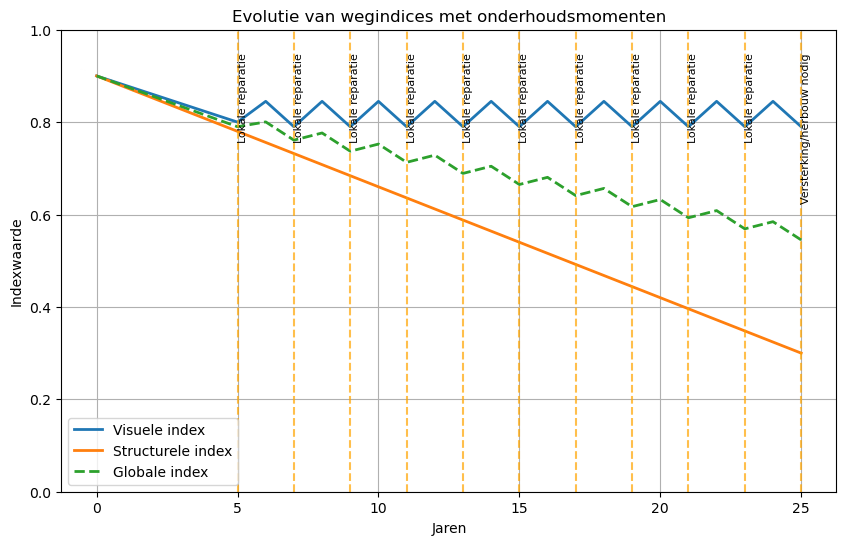

In [19]:
import matplotlib.pyplot as plt

# Parameters
Kv = 1.00   # verkeersbelasting visueel
Ks = 1.20   # verkeersbelasting structureel
T = 0.00    # verkeersgroei (erf = 0.00, verzamel = 0.02, doorgang = 0.04)

Bv = 0.020  # basis afname visuele index
Cv = 0.055  # versnelde afname visuele index (na lokale reparatie)
Bs = 0.020  # afname structurele index

init_visueel = 0.9
init_structureel = 0.9


def evolutie(v0, s0, Bv, max_jaren=40):
    visueel, structureel = v0, s0
    waarden = []
    for jaar in range(1, max_jaren+1):
        visueel -= Kv * (1+T) * Bv
        structureel -= Ks * (1+T) * Bs
        globaal = 0.5 * (visueel + structureel)
        waarden.append((jaar, visueel, structureel, globaal))
        if visueel <= 0 or structureel <= 0:
            break
    return waarden


def tijd_tot_visueel_drempel(v0, s0, Bv, drempel=0.8):
    waarden = evolutie(v0, s0, Bv)
    for jaar, v, s, g in waarden:
        if v <= drempel:
            return jaar
    return None


def tijd_tot_globaal_drempel(v0, s0, Bv, drempel=0.5):
    waarden = evolutie(v0, s0, Bv)
    for jaar, v, s, g in waarden:
        if g <= drempel:
            return jaar
    return None


def simuleer(max_jaren=50):
    jaar = 0
    visueel, structureel = init_visueel, init_structureel
    Bv_actief = Bv

    jaren = [jaar]
    vis_values = [visueel]
    struc_values = [structureel]
    glob_values = [0.5 * (visueel + structureel)]
    events = {}

    while jaar < max_jaren:
        t_lokaal = tijd_tot_visueel_drempel(visueel, structureel, Bv_actief, 0.8)
        t_globaal = tijd_tot_globaal_drempel(visueel, structureel, Bv_actief, 0.5)

        if t_globaal is None:
            break

        if t_lokaal is None or t_globaal <= t_lokaal:
            # Algemene reparatie
            waarden = evolutie(visueel, structureel, Bv_actief, t_globaal)
            for i, (j, v, s, g) in enumerate(waarden, 1):
                jaren.append(jaar + j)
                vis_values.append(v)
                struc_values.append(s)
                glob_values.append(g)
            jaar += t_globaal
            visueel, structureel = waarden[-1][1:3]
            visueel = 0.9
            globaal = 0.5 * (visueel + structureel)
            Bv_actief = Bv
            events[jaar] = "Algemene reparatie"
        else:
            # Lokale reparatie
            waarden = evolutie(visueel, structureel, Bv_actief, t_lokaal)
            for i, (j, v, s, g) in enumerate(waarden, 1):
                jaren.append(jaar + j)
                vis_values.append(v)
                struc_values.append(s)
                glob_values.append(g)
            jaar += t_lokaal
            visueel, structureel = waarden[-1][1:3]
            visueel = 0.9
            globaal = 0.5 * (visueel + structureel)
            Bv_actief = Cv
            events[jaar] = "Lokale reparatie"

        if structureel <= 0.3:
            events[jaar] = "Versterking/herbouw nodig"
            break

    return jaren, vis_values, struc_values, glob_values, events


# Uitvoeren en plotten
jaren, vis_values, struc_values, glob_values, events = simuleer()

plt.figure(figsize=(10,6))
plt.plot(jaren, vis_values, label="Visuele index", linewidth=2)
plt.plot(jaren, struc_values, label="Structurele index", linewidth=2)
plt.plot(jaren, glob_values, label="Globale index", linewidth=2, linestyle="--")

# Events markeren
for j, e in events.items():
    plt.axvline(j, color="red" if "Algemene" in e else "orange", linestyle="--", alpha=0.7)
    plt.text(j, 0.95, e, rotation=90, verticalalignment="top", fontsize=8)

plt.title("Evolutie van wegindices met onderhoudsmomenten")
plt.xlabel("Jaren")
plt.ylabel("Indexwaarde")
plt.ylim(0,1.0)
plt.legend()
plt.grid(True)
plt.show()


In [1]:
# TEST ERF ASFALT 0.9 START INDEX
T = 0.00    # GROEIPERCENTAGE VERKEER (erf= 0.00, verzamel= 0.02, doorgang= 0.04 )
Kv = 1.00   # BELASTING VAN VERKEER (WEGKENMERKEN: Dict[RoadFunctionType, RoadCharacteristics] = {
            #"erf": {"K1": 1.00, "K2": 1.20, "T": 0.00},
            #"verzamel": {"K1": 1.25, "K2": 1.50, "T": 0.02},
            #"doorgang": {"K1": 1.35, "K2": 1.62, "T": 0.04}
Ks = 1.20
Bv = 0.020
Bs = 0.020
v_start = 0.9
s_start = 0.9

jaar = 1
v= v_start -  (Kv*(1+T) * Bv)
s= s_start -  (Ks*(1+T) * Bs)
g = 0.5 * (v+s)
print(f"JAAR {jaar} => visueel: {v} - structureel: {s} - globaal: {g}")

jaar = 2
v2= v_start - ((Kv*(1+T) * Bv)*jaar)
v= v -  (Kv*(1+T) * Bv)
s= s -  (Ks*(1+T) * Bs)
g = 0.5 * (v+s)
print(f"JAAR {jaar} => visueel: {v} {v2} - structureel: {s} - globaal: {g}")

jaar = 3
v= v -  (Kv*(1+T) * Bv)
s= s -  (Ks*(1+T) * Bs)
g = 0.5 * (v+s)
print(f"JAAR {jaar} => visueel: {v} - structureel: {s} - globaal: {g}")

jaar = 4
v= v -  (Kv*(1+T) * Bv)
s= s -  (Ks*(1+T) * Bs)
g = 0.5 * (v+s)
print(f"JAAR {jaar} => visueel: {v} - structureel: {s} - globaal: {g}")

jaar = 5
v= v -  (Kv*(1+T) * Bv)
s= s -  (Ks*(1+T) * Bs)
g = 0.5 * (v+s)
print(f"JAAR {jaar} => visueel: {v} - structureel: {s} - globaal: {g}")

# pas onderhoud Lokaal toe in JAAR 5 MAAR WAARDEN IN JAAR 6 AANPASSEN
Bv = 0.055
v = 0.9

jaar = 6
v= v -  (Kv*(1+T) * Bv)
s= s -  (Ks*(1+T) * Bs)
g = 0.5 * (v+s)
print(f"JAAR {jaar} => visueel: {v} - structureel: {s} - globaal: {g}")


jaar = 7
v= v -  (Kv*(1+T) * Bv)
s= s -  (Ks*(1+T) * Bs)
g = 0.5 * (v+s)
print(f"JAAR {jaar} => visueel: {v} - structureel: {s} - globaal: {g}")

# pas onderhoud Lokaal toe in JAAR 7 MAAR WAARDEN IN JAAR 8 AANPASSEN
Bv = 0.055
v = 0.9

jaar = 8
v= v -  (Kv*(1+T) * Bv)
s= s -  (Ks*(1+T) * Bs)
g = 0.5 * (v+s)
print(f"JAAR {jaar} => visueel: {v} - structureel: {s} - globaal: {g}")

jaar = 9
v= v -  (Kv*(1+T) * Bv)
s= s -  (Ks*(1+T) * Bs)
g = 0.5 * (v+s)
print(f"JAAR {jaar} => visueel: {v} - structureel: {s} - globaal: {g}")


jaar = 10
v= v -  (Kv*(1+T) * Bv)
s= s -  (Ks*(1+T) * Bs)
g = 0.5 * (v+s)
print(f"JAAR {jaar} => visueel: {v} - structureel: {s} - globaal: {g}")

jaar = 11
v= v -  (Kv*(1+T) * Bv)
s= s -  (Ks*(1+T) * Bs)
g = 0.5 * (v+s)
print(f"JAAR {jaar} => visueel: {v} - structureel: {s} - globaal: {g}")

jaar = 12
v= v -  (Kv*(1+T) * Bv)
s= s -  (Ks*(1+T) * Bs)
g = 0.5 * (v+s)
print(f"JAAR {jaar} => visueel: {v} - structureel: {s} - globaal: {g}")

JAAR 1 => visueel: 0.88 - structureel: 0.876 - globaal: 0.878
JAAR 2 => visueel: 0.86 0.86 - structureel: 0.852 - globaal: 0.856
JAAR 3 => visueel: 0.84 - structureel: 0.828 - globaal: 0.834
JAAR 4 => visueel: 0.82 - structureel: 0.8039999999999999 - globaal: 0.8119999999999999
JAAR 5 => visueel: 0.7999999999999999 - structureel: 0.7799999999999999 - globaal: 0.7899999999999999
JAAR 6 => visueel: 0.845 - structureel: 0.7559999999999999 - globaal: 0.8005
JAAR 7 => visueel: 0.7899999999999999 - structureel: 0.7319999999999999 - globaal: 0.7609999999999999
JAAR 8 => visueel: 0.845 - structureel: 0.7079999999999999 - globaal: 0.7765
JAAR 9 => visueel: 0.7899999999999999 - structureel: 0.6839999999999998 - globaal: 0.7369999999999999
JAAR 10 => visueel: 0.7349999999999999 - structureel: 0.6599999999999998 - globaal: 0.6974999999999998
JAAR 11 => visueel: 0.6799999999999998 - structureel: 0.6359999999999998 - globaal: 0.6579999999999998
JAAR 12 => visueel: 0.6249999999999998 - structureel: 0

In [2]:
# TEST ERF ASFALT 0.9 START INDEX
T = 0.00    # GROEIPERCENTAGE VERKEER (erf= 0.00, verzamel= 0.02, doorgang= 0.04 )
Kv = 1.00   # BELASTING VAN VERKEER (WEGKENMERKEN: Dict[RoadFunctionType, RoadCharacteristics] = {
            #"erf": {"K1": 1.00, "K2": 1.20, "T": 0.00},
            #"verzamel": {"K1": 1.25, "K2": 1.50, "T": 0.02},
            #"doorgang": {"K1": 1.35, "K2": 1.62, "T": 0.04}
Ks = 1.20
Bv = 0.020
Bs = 0.020
cumul_visueel = 0
cumul_structu = 0

j = 1
delta_visueel = Kv * (1 + T) * Bv
delta_structu = Ks * (1 + T) * Bs
cumul_visueel += delta_visueel
cumul_structu += delta_structu
print(f"JAAR {j} => visueel: {0.9 - cumul_visueel:.2f} - structureel: {0.9 - cumul_structu:.2f} - globaal: {0.5 * ((0.9 - cumul_visueel)+(0.9 - cumul_structu)):.4f}")

j += 1
delta_visueel = Kv * (1 + T) * Bv
delta_structu = Ks * (1 + T) * Bs
cumul_visueel += delta_visueel
cumul_structu += delta_structu
print(f"JAAR {j} => visueel: {0.9 - cumul_visueel:.2f} - structureel: {0.9 - cumul_structu:.2f} - globaal: {0.5 * ((0.9 - cumul_visueel)+(0.9 - cumul_structu)):.4f}")


j += 1
delta_visueel = Kv * (1 + T) * Bv
delta_structu = Ks * (1 + T) * Bs
cumul_visueel += delta_visueel
cumul_structu += delta_structu
print(f"JAAR {j} => visueel: {0.9 - cumul_visueel:.2f} - structureel: {0.9 - cumul_structu:.2f} - globaal: {0.5 * ((0.9 - cumul_visueel)+(0.9 - cumul_structu)):.4f}")


j += 1
delta_visueel = Kv * (1 + T) * Bv
delta_structu = Ks * (1 + T) * Bs
cumul_visueel += delta_visueel
cumul_structu += delta_structu
print(f"JAAR {j} => visueel: {0.9 - cumul_visueel:.2f} - structureel: {0.9 - cumul_structu:.2f} - globaal: {0.5 * ((0.9 - cumul_visueel)+(0.9 - cumul_structu)):.4f}")


j += 1
delta_visueel = Kv * (1 + T) * Bv
delta_structu = Ks * (1 + T) * Bs
cumul_visueel += delta_visueel
cumul_structu += delta_structu
print(f"JAAR {j} => visueel: {0.9 - cumul_visueel:.2f} - structureel: {0.9 - cumul_structu:.2f} - globaal: {0.5 * ((0.9 - cumul_visueel)+(0.9 - cumul_structu)):.4f}")

# pas onderhoud Lokaal toe in JAAR 5 MAAR WAARDEN IN JAAR 6 AANPASSEN
Bv = 0.030
cumul_visueel = 0

j += 1
delta_visueel = Kv * (1 + T) * Bv
delta_structu = Ks * (1 + T) * Bs
cumul_visueel += delta_visueel
cumul_structu += delta_structu
print(f"JAAR {j} => visueel: {0.9 - cumul_visueel:.2f} - structureel: {0.9 - cumul_structu:.2f} - globaal: {0.5 * ((0.9 - cumul_visueel)+(0.9 - cumul_structu)):.4f}")

j += 1
delta_visueel = Kv * (1 + T) * Bv
delta_structu = Ks * (1 + T) * Bs
cumul_visueel += delta_visueel
cumul_structu += delta_structu
print(f"JAAR {j} => visueel: {0.9 - cumul_visueel:.2f} - structureel: {0.9 - cumul_structu:.2f} - globaal: {0.5 * ((0.9 - cumul_visueel)+(0.9 - cumul_structu)):.4f}")

# pas onderhoud Lokaal toe in JAAR 7 MAAR WAARDEN IN JAAR 8 AANPASSEN
Bv = 0.055
cumul_visueel = 0

j += 1
delta_visueel = Kv * (1 + T) * Bv
delta_structu = Ks * (1 + T) * Bs
cumul_visueel += delta_visueel
cumul_structu += delta_structu
print(f"JAAR {j} => visueel: {0.9 - cumul_visueel:.2f} - structureel: {0.9 - cumul_structu:.2f} - globaal: {0.5 * ((0.9 - cumul_visueel)+(0.9 - cumul_structu)):.4f}")

j += 1
delta_visueel = Kv * (1 + T) * Bv
delta_structu = Ks * (1 + T) * Bs
cumul_visueel += delta_visueel
cumul_structu += delta_structu
print(f"JAAR {j} => visueel: {0.9 - cumul_visueel:.2f} - structureel: {0.9 - cumul_structu:.2f} - globaal: {0.5 * ((0.9 - cumul_visueel)+(0.9 - cumul_structu)):.4f}")

j += 1
delta_visueel = Kv * (1 + T) * Bv
delta_structu = Ks * (1 + T) * Bs
cumul_visueel += delta_visueel
cumul_structu += delta_structu
print(f"JAAR {j} => visueel: {0.9 - cumul_visueel:.2f} - structureel: {0.9 - cumul_structu:.2f} - globaal: {0.5 * ((0.9 - cumul_visueel)+(0.9 - cumul_structu)):.4f}")

j += 1
delta_visueel = Kv * (1 + T) * Bv
delta_structu = Ks * (1 + T) * Bs
cumul_visueel += delta_visueel
cumul_structu += delta_structu
print(f"JAAR {j} => visueel: {0.9 - cumul_visueel:.2f} - structureel: {0.9 - cumul_structu:.2f} - globaal: {0.5 * ((0.9 - cumul_visueel)+(0.9 - cumul_structu)):.4f}")

j += 1
delta_visueel = Kv * (1 + T) * Bv
delta_structu = Ks * (1 + T) * Bs
cumul_visueel += delta_visueel
cumul_structu += delta_structu
print(f"JAAR {j} => visueel: {0.9 - cumul_visueel:.2f} - structureel: {0.9 - cumul_structu:.2f} - globaal: {0.5 * ((0.9 - cumul_visueel)+(0.9 - cumul_structu)):.4f}")

j += 1
delta_visueel = Kv * (1 + T) * Bv
delta_structu = Ks * (1 + T) * Bs
cumul_visueel += delta_visueel
cumul_structu += delta_structu
print(f"JAAR {j} => visueel: {0.9 - cumul_visueel:.2f} - structureel: {0.9 - cumul_structu:.2f} - globaal: {0.5 * ((0.9 - cumul_visueel)+(0.9 - cumul_structu)):.4f}")

j += 1
delta_visueel = Kv * (1 + T) * Bv
delta_structu = Ks * (1 + T) * Bs
cumul_visueel += delta_visueel
cumul_structu += delta_structu
print(f"JAAR {j} => visueel: {0.9 - cumul_visueel:.2f} - structureel: {0.9 - cumul_structu:.2f} - globaal: {0.5 * ((0.9 - cumul_visueel)+(0.9 - cumul_structu)):.4f}")

j += 1
delta_visueel = Kv * (1 + T) * Bv
delta_structu = Ks * (1 + T) * Bs
cumul_visueel += delta_visueel
cumul_structu += delta_structu
print(f"JAAR {j} => visueel: {0.9 - cumul_visueel:.2f} - structureel: {0.9 - cumul_structu:.2f} - globaal: {0.5 * ((0.9 - cumul_visueel)+(0.9 - cumul_structu)):.4f}")

# pas onderhoud Lokaal toe in JAAR 7 MAAR WAARDEN IN JAAR 8 AANPASSEN
Bv = 0.030
cumul_visueel = 0

j += 1
delta_visueel = Kv * (1 + T) * Bv
delta_structu = Ks * (1 + T) * Bs
cumul_visueel += delta_visueel
cumul_structu += delta_structu
print(f"JAAR {j} => visueel: {0.9 - cumul_visueel:.2f} - structureel: {0.9 - cumul_structu:.2f} - globaal: {0.5 * ((0.9 - cumul_visueel)+(0.9 - cumul_structu)):.4f}")

j += 1
delta_visueel = Kv * (1 + T) * Bv
delta_structu = Ks * (1 + T) * Bs
cumul_visueel += delta_visueel
cumul_structu += delta_structu
print(f"JAAR {j} => visueel: {0.9 - cumul_visueel:.2f} - structureel: {0.9 - cumul_structu:.2f} - globaal: {0.5 * ((0.9 - cumul_visueel)+(0.9 - cumul_structu)):.4f}")

j += 1
delta_visueel = Kv * (1 + T) * Bv
delta_structu = Ks * (1 + T) * Bs
cumul_visueel += delta_visueel
cumul_structu += delta_structu
print(f"JAAR {j} => visueel: {0.9 - cumul_visueel:.2f} - structureel: {0.9 - cumul_structu:.2f} - globaal: {0.5 * ((0.9 - cumul_visueel)+(0.9 - cumul_structu)):.4f}")

j += 1
delta_visueel = Kv * (1 + T) * Bv
delta_structu = Ks * (1 + T) * Bs
cumul_visueel += delta_visueel
cumul_structu += delta_structu
print(f"JAAR {j} => visueel: {0.9 - cumul_visueel:.2f} - structureel: {0.9 - cumul_structu:.2f} - globaal: {0.5 * ((0.9 - cumul_visueel)+(0.9 - cumul_structu)):.4f}")

j += 1
delta_visueel = Kv * (1 + T) * Bv
delta_structu = Ks * (1 + T) * Bs
cumul_visueel += delta_visueel
cumul_structu += delta_structu
print(f"JAAR {j} => visueel: {0.9 - cumul_visueel:.2f} - structureel: {0.9 - cumul_structu:.2f} - globaal: {0.5 * ((0.9 - cumul_visueel)+(0.9 - cumul_structu)):.4f}")


JAAR 1 => visueel: 0.88 - structureel: 0.88 - globaal: 0.8780
JAAR 2 => visueel: 0.86 - structureel: 0.85 - globaal: 0.8560
JAAR 3 => visueel: 0.84 - structureel: 0.83 - globaal: 0.8340
JAAR 4 => visueel: 0.82 - structureel: 0.80 - globaal: 0.8120
JAAR 5 => visueel: 0.80 - structureel: 0.78 - globaal: 0.7900
JAAR 6 => visueel: 0.87 - structureel: 0.76 - globaal: 0.8130
JAAR 7 => visueel: 0.84 - structureel: 0.73 - globaal: 0.7860
JAAR 8 => visueel: 0.84 - structureel: 0.71 - globaal: 0.7765
JAAR 9 => visueel: 0.79 - structureel: 0.68 - globaal: 0.7370
JAAR 10 => visueel: 0.73 - structureel: 0.66 - globaal: 0.6975
JAAR 11 => visueel: 0.68 - structureel: 0.64 - globaal: 0.6580
JAAR 12 => visueel: 0.62 - structureel: 0.61 - globaal: 0.6185
JAAR 13 => visueel: 0.57 - structureel: 0.59 - globaal: 0.5790
JAAR 14 => visueel: 0.52 - structureel: 0.56 - globaal: 0.5395
JAAR 15 => visueel: 0.46 - structureel: 0.54 - globaal: 0.5000
JAAR 16 => visueel: 0.87 - structureel: 0.52 - globaal: 0.6930
J

# Vergelijking ERF ASFALT SCENARIO 1 OP 20 JAAR

printscreen van de globale index & onderhoudstype van vorige project

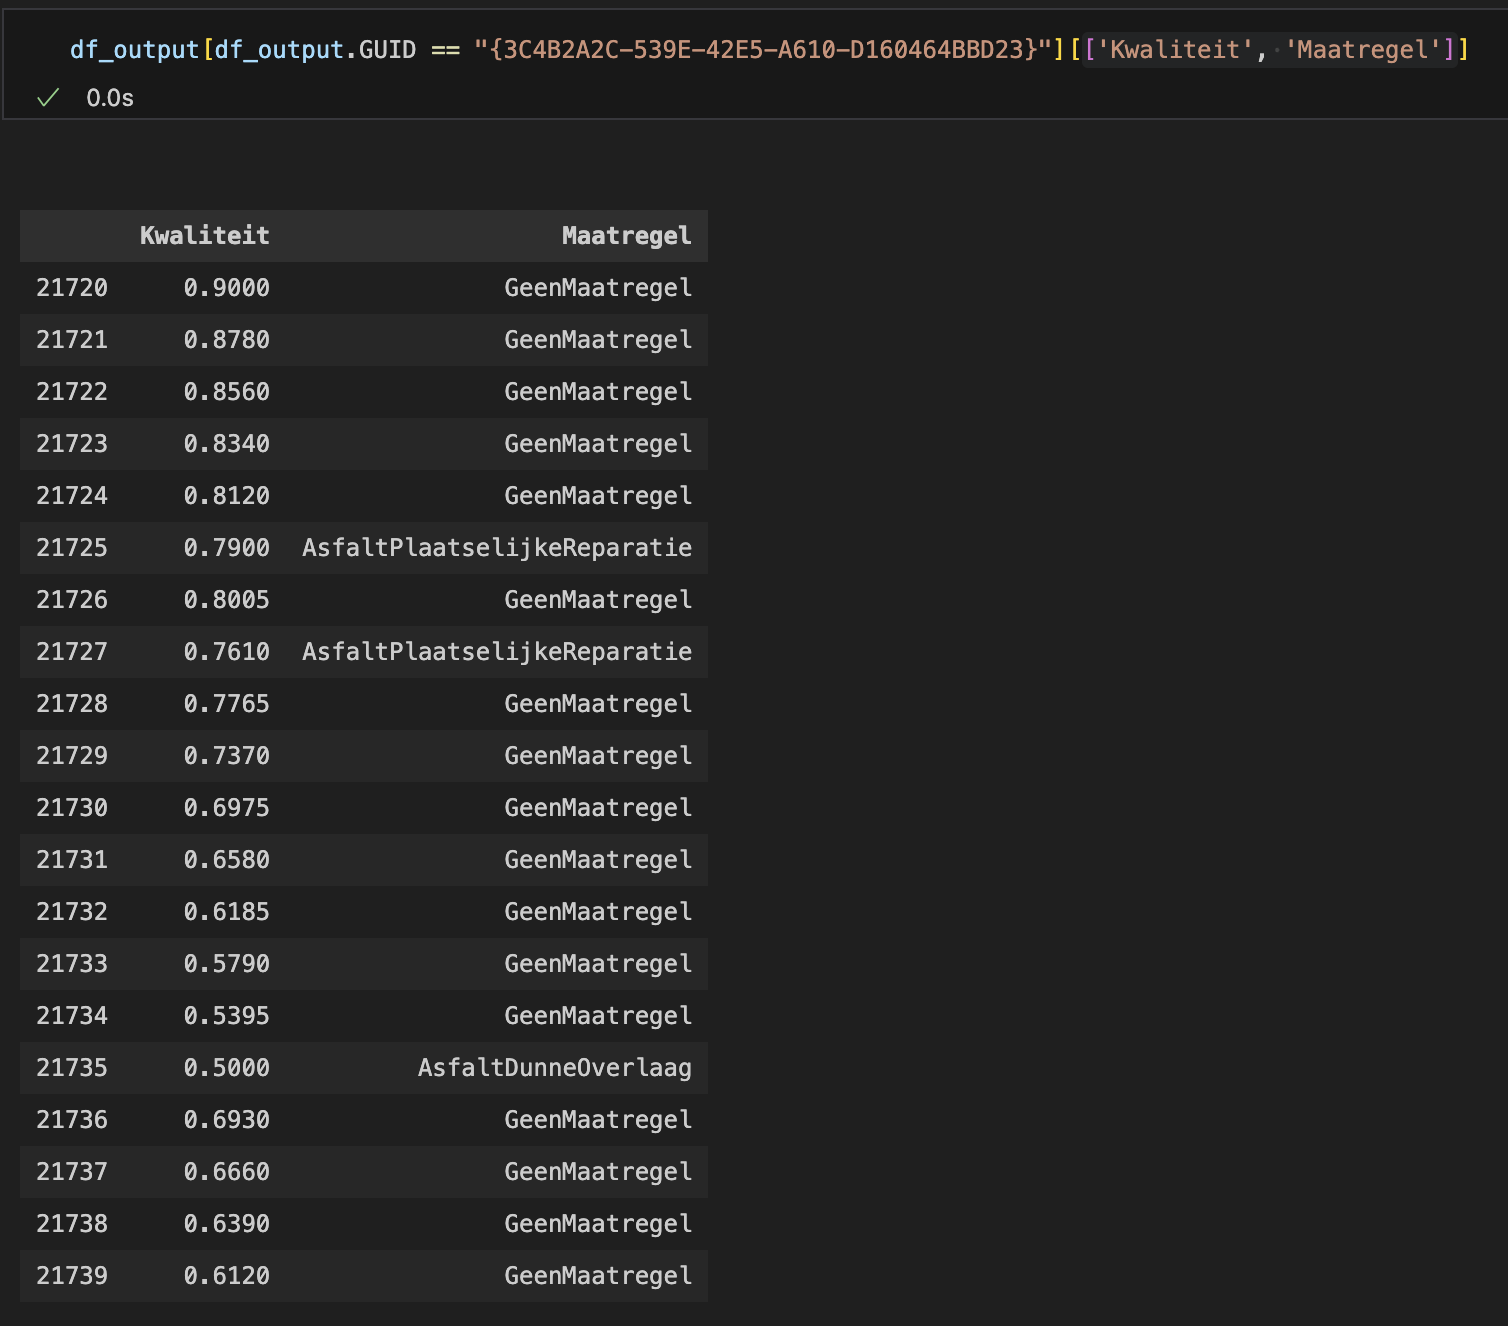

#### Cumul berekening toegepast op de juiste variabele.
- Enkel verharding en functie moet nog meegegeven worden.
- scenarios toegevoegd die bepalen wat de drempel zal worden en adhv scenario nummer een onderhoud gaat voorstellen.
- gelinkt aan het onderhoud zal in de OCW formule waarde B veranderen
- ook kan comul_B & comul_W op nul gezet worden (comul_B bij lokaal, herstelling_vx, versterking_vx) (comul_W enkel bij versterking_vx)

import numpy as np
from ocw_project.config.app_config import MaintenanceManager
from ocw_project.Road_Parameters import ROAD_DATA, initialize_simulation

verharding = "asfalt"
functie = "erf"

wk = initialize_simulation(verharding=verharding, functie=functie)

print("START")
print(f"\njaar_0 => visueel= {wk.visueel:.2f} - structureel= {wk.structureel:.2f} - globaal= {wk.globaal:.2f}")
print(f"onderhoud= {wk.onderhouds_type}, {wk.current_B}, {wk.cumul_B}")

for i in range(1,30):
    # CHECK SCENARIO DREMPELS ALS HET OVERGANG IS ONDERHOUD AANPASSEN
    # ALS LOKAAL OF HERSTELLING IS cumul_B = 0 + B waarde aanpassen
    # ALS VERSTERKING RESET ZOALS LOKAAL 1 HERSTELLING + cumul_X
        
    delta_B = wk.K1 * (1 + wk.T) * wk.current_B
    delta_X = wk.K2 * (1 + wk.T) * wk.W
    wk.cumul_B += delta_B
    wk.cumul_W += delta_X
    wk.visueel = 0.9 - wk.cumul_B
    wk.structureel = 0.9 - wk.cumul_W
    wk.g_min1 = wk.globaal
    wk.globaal = 0.5 * (wk.visueel+wk.structureel)
    wk.onderhouds_type = MaintenanceManager.get_maintenance_type(scenario_id=1, G=wk.globaal, G_min1=wk.g_min1)

    if wk.onderhouds_type is not None and wk.onderhouds_type != 'routine':
        if wk.onderhouds_type == 'lokaal':
            wk.cumul_B = 0
        elif wk.onderhouds_type.startswith('algemeen'):
            wk.cumul_B = 0
        elif wk.onderhouds_type.startswith('versterking'):
            wk.cumul_B, wk.cumul_W = 0, 0

        wk.current_B = ROAD_DATA[wk.verharding].onderhoud_B.get(
        wk.onderhouds_type, 
        ROAD_DATA[wk.verharding].BW_standaard['B']
        )

    print(f"\njaar_{i} => visueel= {wk.visueel:.2f} - structureel= {wk.structureel:.2f} - globaal= {wk.globaal:.4f}")
    print(f"onderhoud= {wk.onderhouds_type}, {wk.current_B}, {wk.cumul_B}")

In [3]:
# TEST VERZAMEL asfalt 0.9 START INDEX
T = 0.00    # GROEIPERCENTAGE VERKEER (erf= 0.00, verzamel= 0.02, doorgang= 0.04 )
Kv = 1.25   # BELASTING VAN VERKEER (WEGKENMERKEN: Dict[RoadFunctionType, RoadCharacteristics] = {
            #"erf": {"K1": 1.00, "K2": 1.20, "T": 0.00},
            #"verzamel": {"K1": 1.25, "K2": 1.50, "T": 0.02},
            #"doorgang": {"K1": 1.35, "K2": 1.62, "T": 0.04}
Ks = 1.50
Bv = 0.020
Bs = 0.020
cumul_visueel = 0.9 - 0.839508
cumul_structu = 0.9 - 0.856792
print(f"JAAR {0} => visueel: {0.9 - cumul_visueel:.2f} - structureel: {0.9 - cumul_structu:.2f} - globaal: {0.5 * ((0.9 - cumul_visueel)+(0.9 - cumul_structu)):.5f}")

j = 1
delta_visueel = Kv * (1 + T) * Bv
delta_structu = Ks * (1 + T) * Bs
cumul_visueel += delta_visueel
cumul_structu += delta_structu
print(f"JAAR {j} => visueel: {0.9 - cumul_visueel:.2f} - structureel: {0.9 - cumul_structu:.2f} - globaal: {0.5 * ((0.9 - cumul_visueel)+(0.9 - cumul_structu)):.5f}")

j += 1
delta_visueel = Kv * (1 + T) * Bv
delta_structu = Ks * (1 + T) * Bs
cumul_visueel += delta_visueel
cumul_structu += delta_structu
print(f"JAAR {j} => visueel: {0.9 - cumul_visueel:.2f} - structureel: {0.9 - cumul_structu:.2f} - globaal: {0.5 * ((0.9 - cumul_visueel)+(0.9 - cumul_structu)):.5f}")

cumul_visueel = 0
Bv = 0.055
j += 1
delta_visueel = Kv * (1 + T) * Bv
delta_structu = Ks * (1 + T) * Bs
cumul_visueel += delta_visueel
cumul_structu += delta_structu
print(f"JAAR {j} => visueel: {0.9 - cumul_visueel:.2f} - structureel: {0.9 - cumul_structu:.2f} - globaal: {0.5 * ((0.9 - cumul_visueel)+(0.9 - cumul_structu)):.5f}")


j += 1
delta_visueel = Kv * (1 + T) * Bv
delta_structu = Ks * (1 + T) * Bs
cumul_visueel += delta_visueel
cumul_structu += delta_structu
print(f"JAAR {j} => visueel: {0.9 - cumul_visueel:.2f} - structureel: {0.9 - cumul_structu:.2f} - globaal: {0.5 * ((0.9 - cumul_visueel)+(0.9 - cumul_structu)):.4f}")


j += 1
delta_visueel = Kv * (1 + T) * Bv
delta_structu = Ks * (1 + T) * Bs
cumul_visueel += delta_visueel
cumul_structu += delta_structu
print(f"JAAR {j} => visueel: {0.9 - cumul_visueel:.2f} - structureel: {0.9 - cumul_structu:.2f} - globaal: {0.5 * ((0.9 - cumul_visueel)+(0.9 - cumul_structu)):.4f}")


j += 1
delta_visueel = Kv * (1 + T) * Bv
delta_structu = Ks * (1 + T) * Bs
cumul_visueel += delta_visueel
cumul_structu += delta_structu
print(f"JAAR {j} => visueel: {0.9 - cumul_visueel:.2f} - structureel: {0.9 - cumul_structu:.2f} - globaal: {0.5 * ((0.9 - cumul_visueel)+(0.9 - cumul_structu)):.4f}")

j += 1
delta_visueel = Kv * (1 + T) * Bv
delta_structu = Ks * (1 + T) * Bs
cumul_visueel += delta_visueel
cumul_structu += delta_structu
print(f"JAAR {j} => visueel: {0.9 - cumul_visueel:.2f} - structureel: {0.9 - cumul_structu:.2f} - globaal: {0.5 * ((0.9 - cumul_visueel)+(0.9 - cumul_structu)):.4f}")

# pas onderhoud Lokaal toe in JAAR 7 MAAR WAARDEN IN JAAR 8 AANPASSEN
Bv = 0.016
cumul_visueel = 0

j += 1
delta_visueel = Kv * (1 + T) * Bv
delta_structu = Ks * (1 + T) * Bs
cumul_visueel += delta_visueel
cumul_structu += delta_structu
print(f"JAAR {j} => visueel: {0.9 - cumul_visueel:.2f} - structureel: {0.9 - cumul_structu:.2f} - globaal: {0.5 * ((0.9 - cumul_visueel)+(0.9 - cumul_structu)):.4f}")

j += 1
delta_visueel = Kv * (1 + T) * Bv
delta_structu = Ks * (1 + T) * Bs
cumul_visueel += delta_visueel
cumul_structu += delta_structu
print(f"JAAR {j} => visueel: {0.9 - cumul_visueel:.2f} - structureel: {0.9 - cumul_structu:.2f} - globaal: {0.5 * ((0.9 - cumul_visueel)+(0.9 - cumul_structu)):.4f}")

j += 1
delta_visueel = Kv * (1 + T) * Bv
delta_structu = Ks * (1 + T) * Bs
cumul_visueel += delta_visueel
cumul_structu += delta_structu
print(f"JAAR {j} => visueel: {0.9 - cumul_visueel:.2f} - structureel: {0.9 - cumul_structu:.2f} - globaal: {0.5 * ((0.9 - cumul_visueel)+(0.9 - cumul_structu)):.4f}")

j += 1
delta_visueel = Kv * (1 + T) * Bv
delta_structu = Ks * (1 + T) * Bs
cumul_visueel += delta_visueel
cumul_structu += delta_structu
print(f"JAAR {j} => visueel: {0.9 - cumul_visueel:.2f} - structureel: {0.9 - cumul_structu:.2f} - globaal: {0.5 * ((0.9 - cumul_visueel)+(0.9 - cumul_structu)):.4f}")

j += 1
delta_visueel = Kv * (1 + T) * Bv
delta_structu = Ks * (1 + T) * Bs
cumul_visueel += delta_visueel
cumul_structu += delta_structu
print(f"JAAR {j} => visueel: {0.9 - cumul_visueel:.2f} - structureel: {0.9 - cumul_structu:.2f} - globaal: {0.5 * ((0.9 - cumul_visueel)+(0.9 - cumul_structu)):.4f}")

j += 1
delta_visueel = Kv * (1 + T) * Bv
delta_structu = Ks * (1 + T) * Bs
cumul_visueel += delta_visueel
cumul_structu += delta_structu
print(f"JAAR {j} => visueel: {0.9 - cumul_visueel:.2f} - structureel: {0.9 - cumul_structu:.2f} - globaal: {0.5 * ((0.9 - cumul_visueel)+(0.9 - cumul_structu)):.4f}")

j += 1
delta_visueel = Kv * (1 + T) * Bv
delta_structu = Ks * (1 + T) * Bs
cumul_visueel += delta_visueel
cumul_structu += delta_structu
print(f"JAAR {j} => visueel: {0.9 - cumul_visueel:.2f} - structureel: {0.9 - cumul_structu:.2f} - globaal: {0.5 * ((0.9 - cumul_visueel)+(0.9 - cumul_structu)):.4f}")

j += 1
delta_visueel = Kv * (1 + T) * Bv
delta_structu = Ks * (1 + T) * Bs
cumul_visueel += delta_visueel
cumul_structu += delta_structu
print(f"JAAR {j} => visueel: {0.9 - cumul_visueel:.2f} - structureel: {0.9 - cumul_structu:.2f} - globaal: {0.5 * ((0.9 - cumul_visueel)+(0.9 - cumul_structu)):.4f}")

# pas onderhoud Lokaal toe in JAAR 7 MAAR WAARDEN IN JAAR 8 AANPASSEN
Bv = 0.030
cumul_visueel = 0

j += 1
delta_visueel = Kv * (1 + T) * Bv
delta_structu = Ks * (1 + T) * Bs
cumul_visueel += delta_visueel
cumul_structu += delta_structu
print(f"JAAR {j} => visueel: {0.9 - cumul_visueel:.2f} - structureel: {0.9 - cumul_structu:.2f} - globaal: {0.5 * ((0.9 - cumul_visueel)+(0.9 - cumul_structu)):.4f}")

j += 1
delta_visueel = Kv * (1 + T) * Bv
delta_structu = Ks * (1 + T) * Bs
cumul_visueel += delta_visueel
cumul_structu += delta_structu
print(f"JAAR {j} => visueel: {0.9 - cumul_visueel:.2f} - structureel: {0.9 - cumul_structu:.2f} - globaal: {0.5 * ((0.9 - cumul_visueel)+(0.9 - cumul_structu)):.4f}")

j += 1
delta_visueel = Kv * (1 + T) * Bv
delta_structu = Ks * (1 + T) * Bs
cumul_visueel += delta_visueel
cumul_structu += delta_structu
print(f"JAAR {j} => visueel: {0.9 - cumul_visueel:.2f} - structureel: {0.9 - cumul_structu:.2f} - globaal: {0.5 * ((0.9 - cumul_visueel)+(0.9 - cumul_structu)):.4f}")

j += 1
delta_visueel = Kv * (1 + T) * Bv
delta_structu = Ks * (1 + T) * Bs
cumul_visueel += delta_visueel
cumul_structu += delta_structu
print(f"JAAR {j} => visueel: {0.9 - cumul_visueel:.2f} - structureel: {0.9 - cumul_structu:.2f} - globaal: {0.5 * ((0.9 - cumul_visueel)+(0.9 - cumul_structu)):.4f}")

j += 1
delta_visueel = Kv * (1 + T) * Bv
delta_structu = Ks * (1 + T) * Bs
cumul_visueel += delta_visueel
cumul_structu += delta_structu
print(f"JAAR {j} => visueel: {0.9 - cumul_visueel:.2f} - structureel: {0.9 - cumul_structu:.2f} - globaal: {0.5 * ((0.9 - cumul_visueel)+(0.9 - cumul_structu)):.4f}")


JAAR 0 => visueel: 0.84 - structureel: 0.86 - globaal: 0.84815
JAAR 1 => visueel: 0.81 - structureel: 0.83 - globaal: 0.82065
JAAR 2 => visueel: 0.79 - structureel: 0.80 - globaal: 0.79315
JAAR 3 => visueel: 0.83 - structureel: 0.77 - globaal: 0.79902
JAAR 4 => visueel: 0.76 - structureel: 0.74 - globaal: 0.7496
JAAR 5 => visueel: 0.69 - structureel: 0.71 - globaal: 0.7003
JAAR 6 => visueel: 0.62 - structureel: 0.68 - globaal: 0.6509
JAAR 7 => visueel: 0.56 - structureel: 0.65 - globaal: 0.6015
JAAR 8 => visueel: 0.88 - structureel: 0.62 - globaal: 0.7484
JAAR 9 => visueel: 0.86 - structureel: 0.59 - globaal: 0.7234
JAAR 10 => visueel: 0.84 - structureel: 0.56 - globaal: 0.6984
JAAR 11 => visueel: 0.82 - structureel: 0.53 - globaal: 0.6734
JAAR 12 => visueel: 0.80 - structureel: 0.50 - globaal: 0.6484
JAAR 13 => visueel: 0.78 - structureel: 0.47 - globaal: 0.6234
JAAR 14 => visueel: 0.76 - structureel: 0.44 - globaal: 0.5984
JAAR 15 => visueel: 0.74 - structureel: 0.41 - globaal: 0.573